# CMF Task Part 2 Implementation

This notebook implements the coding part of the task in Python 3.11.

Scope implemented now:

- Baseline single-asset strategy for Solana (SOL-USD).
- Econometric, machine learning, and agent-based signal models for Solana.
- Static portfolio management for seven core cryptocurrencies.
- Dynamic rebalancing for the small seven-coin portfolio.
- Expanded dynamic portfolio allocation across every eligible coin in the broad local crypto data snapshot.

The expanded portfolio uses the committed local OHLCV snapshot rather than a live feed during notebook execution. Coins with stale or incomplete raw data are reported and excluded before the dynamic allocation runs.

The notebook uses the committed local file data/crypto_ohlcv.csv by default, so the backtests are reproducible without live data calls.


## 0. Imports, Configuration, and Data Loading

We use daily crypto candles and annualize by 365 days because spot crypto trades continuously. Transaction costs are modeled as 10 basis points per unit of turnover, to stop the models from benefiting from tiny prediction noise.

In [37]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import math
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

DATA_PATH = Path("data/crypto_ohlcv.csv")
BASELINE_TICKER = "SOL-USD"

# The first seven coins are kept as the small portfolio used in sections 4 and 5.
PORTFOLIO_TICKERS = [
    "BTC-USD",
    "ETH-USD",
    "SOL-USD",
    "XRP-USD",
    "ADA-USD",
    "DOGE-USD",
    "LINK-USD",
]

# None means the final expanded portfolio starts from every ticker in the OHLCV CSV.
# The eligibility cell later removes stale or incomplete coins before trading.
EXPANDED_TICKERS: list[str] | None = None

# Stablecoins stay in the CSV as part of the available crypto-pair universe, but
# cash is modelled separately, so they are excluded from the risky alpha book.
EXCLUDED_EXPANDED_TICKERS = {
    "USDT-USD",
    "USDC-USD",
    "DAI-USD",
    "FDUSD-USD",
    "TUSD-USD",
    "USDD-USD",
    "BUSD-USD",
}

ANNUALIZATION = 365
COST_BPS = 10.0
INITIAL_CAPITAL = 1.0

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 13


In [38]:
raw = pd.read_csv(DATA_PATH, parse_dates=["Date"])
raw = raw.sort_values(["Date", "Ticker"]).reset_index(drop=True)

# Raw pivots are kept for data-quality checks. Forward-filled matrices are used only
# after a coin passes the raw-data eligibility rules in the expanded section.
raw_close = raw.pivot(index="Date", columns="Ticker", values="Adj Close").sort_index()
raw_high = raw.pivot(index="Date", columns="Ticker", values="High").sort_index()
raw_low = raw.pivot(index="Date", columns="Ticker", values="Low").sort_index()
raw_volume = raw.pivot(index="Date", columns="Ticker", values="Volume").sort_index()

if EXPANDED_TICKERS is None:
    available_expanded_tickers = sorted(raw_close.columns.tolist())
    missing_expanded_tickers = []
else:
    available_expanded_tickers = [ticker for ticker in EXPANDED_TICKERS if ticker in raw_close.columns]
    missing_expanded_tickers = [ticker for ticker in EXPANDED_TICKERS if ticker not in raw_close.columns]

all_close = raw_close[available_expanded_tickers].ffill()
all_high = raw_high[available_expanded_tickers].ffill().reindex(all_close.index)
all_low = raw_low[available_expanded_tickers].ffill().reindex(all_close.index)
all_volume = raw_volume[available_expanded_tickers].ffill().reindex(all_close.index)
all_returns = all_close.pct_change(fill_method=None)

# The original small portfolio is left unchanged so earlier sections stay comparable.
close = all_close[PORTFOLIO_TICKERS].dropna(how="any")
high = all_high[PORTFOLIO_TICKERS].reindex(close.index)
low = all_low[PORTFOLIO_TICKERS].reindex(close.index)
volume = all_volume[PORTFOLIO_TICKERS].reindex(close.index)
returns = close.pct_change(fill_method=None).dropna(how="any")

last_date = close.index.max()
test_start = last_date - pd.Timedelta(days=365)
train_end = close.index[close.index <= test_start].max()
estimation_start = train_end - pd.Timedelta(days=365)

train_mask = close.index <= train_end
test_mask = close.index > train_end
return_test_mask = returns.index > train_end

print(f"Data rows: {len(close):,} daily observations")
print(f"Date range: {close.index.min().date()} to {close.index.max().date()}")
print(f"Single-asset and portfolio train window ends: {train_end.date()}")
print(f"Out-of-sample test window: {close.index[test_mask].min().date()} to {close.index[test_mask].max().date()}")
print(f"Small-portfolio coins: {', '.join(PORTFOLIO_TICKERS)}")
print(f"Expanded candidates in local data: {len(available_expanded_tickers)} coins")
if missing_expanded_tickers:
    print(f"Expanded candidates missing from local data: {', '.join(missing_expanded_tickers)}")


Data rows: 1,268 daily observations
Date range: 2023-01-01 to 2026-06-21
Single-asset and portfolio train window ends: 2025-06-21
Out-of-sample test window: 2025-06-22 to 2026-06-21
Small-portfolio coins: BTC-USD, ETH-USD, SOL-USD, XRP-USD, ADA-USD, DOGE-USD, LINK-USD
Expanded candidates in local data: 135 coins


## 1. Shared Backtesting and Risk Metric Utilities

The utilities below are and used for baseline, econometric, ML, and AI-agent strategies, which keeps comparisons fair.

In [ ]:
def equity_curve(strategy_returns: pd.Series) -> pd.Series:
    strategy_returns = strategy_returns.fillna(0.0)
    return (1.0 + strategy_returns).cumprod() * INITIAL_CAPITAL


def max_drawdown(strategy_returns: pd.Series) -> float:
    equity = equity_curve(strategy_returns)
    running_peak = equity.cummax()
    drawdown = equity / running_peak - 1.0
    return float(drawdown.min())


def annualized_return(strategy_returns: pd.Series) -> float:
    strategy_returns = strategy_returns.dropna()
    if len(strategy_returns) == 0:
        return np.nan
    equity = equity_curve(strategy_returns).iloc[-1]
    years = len(strategy_returns) / ANNUALIZATION
    if equity <= 0 or years <= 0:
        return np.nan
    return float(equity ** (1.0 / years) - 1.0)


def performance_metrics(
    strategy_returns: pd.Series,
    position: pd.Series | None = None,
    turnover: pd.Series | None = None,
) -> dict[str, float]:
    # Metrics are restricted to the requested research set.
    r = strategy_returns.dropna()
    if len(r) == 0:
        return {}

    ann_ret = annualized_return(r)
    sharpe = float((r.mean() / r.std(ddof=0)) * math.sqrt(ANNUALIZATION)) if r.std(ddof=0) > 0 else np.nan
    mdd = max_drawdown(r)
    if turnover is not None:
        aligned_turnover = turnover.reindex(r.index).fillna(0.0)
        avg_turnover = float(aligned_turnover.mean())
    else:
        avg_turnover = 0.0

    # Margin measures return per unit of annualized traded weight. It is
    # undefined when there is effectively no turnover in the window.
    annualized_turnover = avg_turnover * ANNUALIZATION
    margin = float(ann_ret / annualized_turnover) if annualized_turnover > 1e-12 else np.nan

    # WorldQuant-style fitness (sharpe * sqrt(ret)) / max(turnover, 0.125)
    if np.isfinite(sharpe) and np.isfinite(ann_ret):
        fitness = float(sharpe * math.sqrt(abs(ann_ret) / max(avg_turnover, 0.125)))
    else:
        fitness = np.nan

    metrics = {
        "ROI": float(equity_curve(r).iloc[-1] - 1.0),
        "Returns": ann_ret,
        "Sharpe": sharpe,
        "Drawdown": mdd,
        "Turnover": avg_turnover,
        "Margin": margin,
        "Fitness": fitness,
    }
    return metrics


def strategy_returns_from_position(
    price: pd.Series,
    raw_position: pd.Series,
    cost_bps: float = COST_BPS,
) -> tuple[pd.Series, pd.Series, pd.Series]:
    # Signals are observed at the close and traded for the next bar.
    # The shift prevents look-ahead bias.
    raw_position = raw_position.reindex(price.index).ffill().fillna(0.0).clip(0.0, 1.0)
    executed_position = raw_position.shift(1).fillna(0.0)
    asset_return = price.pct_change().fillna(0.0)

    turnover = executed_position.diff().abs().fillna(executed_position.abs())
    trading_cost = turnover * (cost_bps / 10_000.0)
    net_return = executed_position * asset_return - trading_cost
    return net_return, executed_position, turnover


def print_metrics_table(metrics: dict[str, dict[str, float]], title: str) -> pd.DataFrame:
    table = pd.DataFrame(metrics).T
    ordered = ["ROI", "Returns", "Sharpe", "Drawdown", "Turnover", "Margin", "Fitness"]
    table = table[[c for c in ordered if c in table.columns]]
    print(title)
    print(table.round(4).to_string())
    return table


def ts_rank(series: pd.Series, window: int = 252) -> pd.Series:
    # Time-series rank of the current value inside its trailing window.
    # The result is in [0, 1], where 1 means the current value is high
    # versus its own recent history.
    return series.rolling(window).apply(
        lambda values: pd.Series(values).rank(pct=True).iloc[-1],
        raw=False,
    )


def ts_backfill(series: pd.Series, lookback: int = 5) -> pd.Series:
    # WorldQuant-style backfill: use the most recent available value,
    # but only if it is no older than the requested lookback.
    return series.ffill(limit=lookback)

Requested metric set used throughout:

- `ROI`: total return over the evaluated period.
- `Returns`: annualized compounded return.
- `Sharpe`: annualized risk-adjusted return.
- `Turnover`: average daily traded weight.
- `Fitness`: turnover-aware alpha score, `Sharpe * sqrt(abs(Returns) / max(Turnover, 0.125))`.
- `Drawdown`: worst peak-to-trough equity decline.
- `Margin`: annualized return per unit of annualized turnover.
- Weight distribution: allocation across assets or cash, shown as separate tables/plots instead of as a scalar metric.

## 2. Baseline Strategy for Solana

For SOL baseline I am using three different formulas: a long/cash moving-average crossover on `SOL-USD`: the signal goes long when the 20-day moving average is above the 80-day moving average and goes to cash otherwise.

I wanted to adapt a equity alphas `ts_rank(operating_income/cap, 252)`. SOL is not an operating company with an income statement and balance sheet. To preserve the idea without inventing fake fundamentals, I add this strategy, though it is not working very profitable:

`ts_rank(63-day momentum / 20-day realized volatility, 252)`

The extra volatility-ratio idea is also included:

`ts_backfill(implied_volatility_call_120, 5) / ts_backfill(parkinson_volatility_120, 5)`

In [ ]:
sol_close = close[BASELINE_TICKER]
sol_high = high[BASELINE_TICKER]
sol_low = low[BASELINE_TICKER]
fast_window = 20
slow_window = 80

ma_fast = sol_close.rolling(fast_window).mean()
ma_slow = sol_close.rolling(slow_window).mean()

# Baseline long/cash signal. NaN warm-up periods naturally map to cash.
baseline_signal = (ma_fast > ma_slow).astype(float)
baseline_returns, baseline_position, baseline_turnover = strategy_returns_from_position(sol_close, baseline_signal)

# `ts_rank(63-day momentum / 20-day realized volatility, 252)`
# analogue of ts_rank(operating_income / cap, 252).
realized_vol_20 = sol_close.pct_change().rolling(20).std()
trend_quality = sol_close.pct_change(63) / realized_vol_20.replace(0.0, np.nan)
rank_factor = ts_rank(trend_quality, 252).fillna(0.0)

# Pick a simple threshold using train data only, then freeze it for OOS.
threshold_candidates = [0.50, 0.55, 0.60, 0.65, 0.70]
threshold_scores: dict[float, float] = {}
for threshold in threshold_candidates:
    candidate_signal = (rank_factor > threshold).astype(float)
    candidate_returns, _, candidate_turnover = strategy_returns_from_position(sol_close, candidate_signal)
    candidate_metrics = performance_metrics(
        candidate_returns.loc[train_mask],
        turnover=candidate_turnover.loc[train_mask],
    )
    threshold_scores[threshold] = candidate_metrics.get("Fitness", -np.inf)

rank_threshold = max(threshold_scores, key=threshold_scores.get)
rank_signal = (rank_factor > rank_threshold).astype(float)
rank_returns, rank_position, rank_turnover = strategy_returns_from_position(sol_close, rank_signal)

# Volatility-ratio factor:
# ts_backfill(implied_volatility_call_120, 5) /
# ts_backfill(parkinson_volatility_120, 5)
iv_path = Path("data/sol_implied_volatility_call_120.csv")
if iv_path.exists():
    iv_frame = pd.read_csv(iv_path, parse_dates=["Date"]).set_index("Date").sort_index()
    iv_candidates = ["implied_volatility_call_120", "IV", "iv", "implied_volatility"]
    iv_column = next((col for col in iv_candidates if col in iv_frame.columns), None)
    if iv_column is None:
        raise ValueError(f"{iv_path} must contain one of: {iv_candidates}")
    implied_volatility_call_120 = iv_frame[iv_column].reindex(sol_close.index).astype(float)
    if implied_volatility_call_120.dropna().median() > 3.0:
        implied_volatility_call_120 = implied_volatility_call_120 / 100.0
    if "source" in iv_frame.columns and iv_frame["source"].dropna().nunique() > 0:
        source_label = str(iv_frame["source"].dropna().iloc[0])
        implied_vol_source = f"{source_label} from {iv_path.name}"
    else:
        implied_vol_source = f"external IV file: {iv_path.name}"
else:
    close_to_close_vol_120 = sol_close.pct_change().rolling(120).std() * math.sqrt(ANNUALIZATION)
    implied_volatility_call_120 = close_to_close_vol_120.ewm(span=20, min_periods=10).mean() * 1.10
    implied_vol_source = "proxy: 120-day realized volatility EWMA plus 10% premium"

log_high_low = np.log(sol_high / sol_low).replace([np.inf, -np.inf], np.nan)
parkinson_variance_120 = (log_high_low ** 2).rolling(120).mean() / (4.0 * np.log(2.0))
parkinson_volatility_120 = np.sqrt(parkinson_variance_120 * ANNUALIZATION)

iv_parkinson_ratio = (
    ts_backfill(implied_volatility_call_120, 5)
    / ts_backfill(parkinson_volatility_120, 5).replace(0.0, np.nan)
).replace([np.inf, -np.inf], np.nan)

# IV/Parkinson regimes worked better before the OOS split.
ratio_train = iv_parkinson_ratio.loc[train_mask].dropna()
ratio_threshold_candidates = ratio_train.quantile([0.30, 0.40, 0.50, 0.60, 0.70]).dropna().unique()
ratio_scores: dict[tuple[str, float], float] = {}
for threshold in ratio_threshold_candidates:
    for direction in ["high", "low"]:
        if direction == "high":
            candidate_signal = (iv_parkinson_ratio > threshold).astype(float)
        else:
            candidate_signal = (iv_parkinson_ratio < threshold).astype(float)
        candidate_returns, _, candidate_turnover = strategy_returns_from_position(sol_close, candidate_signal)
        candidate_metrics = performance_metrics(
            candidate_returns.loc[train_mask],
            turnover=candidate_turnover.loc[train_mask],
        )
        ratio_scores[(direction, float(threshold))] = candidate_metrics.get("Fitness", -np.inf)

ratio_direction, ratio_threshold = max(ratio_scores, key=ratio_scores.get)
if ratio_direction == "high":
    vol_ratio_signal = (iv_parkinson_ratio > ratio_threshold).astype(float)
else:
    vol_ratio_signal = (iv_parkinson_ratio < ratio_threshold).astype(float)
vol_ratio_returns, vol_ratio_position, vol_ratio_turnover = strategy_returns_from_position(sol_close, vol_ratio_signal)

buy_hold_signal = pd.Series(1.0, index=sol_close.index)
buy_hold_returns, buy_hold_position, buy_hold_turnover = strategy_returns_from_position(sol_close, buy_hold_signal, cost_bps=0.0)

baseline_metrics = {
    "Buy and Hold SOL": performance_metrics(
        buy_hold_returns.loc[test_mask],
        buy_hold_position.loc[test_mask],
        buy_hold_turnover.loc[test_mask],
    ),
    "MA 20/80 Baseline": performance_metrics(
        baseline_returns.loc[test_mask],
        baseline_position.loc[test_mask],
        baseline_turnover.loc[test_mask],
    ),
    "TS-Rank Crypto Factor": performance_metrics(
        rank_returns.loc[test_mask],
        rank_position.loc[test_mask],
        rank_turnover.loc[test_mask],
    ),
    "IV/Parkinson Vol Ratio": performance_metrics(
        vol_ratio_returns.loc[test_mask],
        vol_ratio_position.loc[test_mask],
        vol_ratio_turnover.loc[test_mask],
    ),
}
baseline_table = print_metrics_table(baseline_metrics, "Out-of-sample Solana baseline and factor metrics")
print(f"Selected TS-rank threshold from train fitness: {rank_threshold:.2f}")
print(f"IV source: {implied_vol_source}")
print(f"Selected IV/Parkinson rule from train fitness: ratio is {ratio_direction} threshold {ratio_threshold:.3f}")

Out-of-sample Solana baseline and factor metrics
                           ROI  Returns  Sharpe  Drawdown  Turnover  Margin  Fitness
Buy and Hold SOL       -0.4642  -0.4642 -0.5013   -0.7489    0.0000     NaN  -0.9660
MA 20/80 Baseline      -0.1343  -0.1343 -0.0829   -0.3641    0.0247 -0.0149  -0.0859
TS-Rank Crypto Factor  -0.2200  -0.2200 -0.2887   -0.4999    0.0466 -0.0129  -0.3830
IV/Parkinson Vol Ratio -0.1052  -0.1052  0.1074   -0.5806    0.0164 -0.0175   0.0985
Selected TS-rank threshold from train fitness: 0.50
IV source: proxy_ewma_realized_vol_120_plus_10pct from sol_implied_volatility_call_120.csv
Selected IV/Parkinson rule from train fitness: ratio is high threshold 1.100


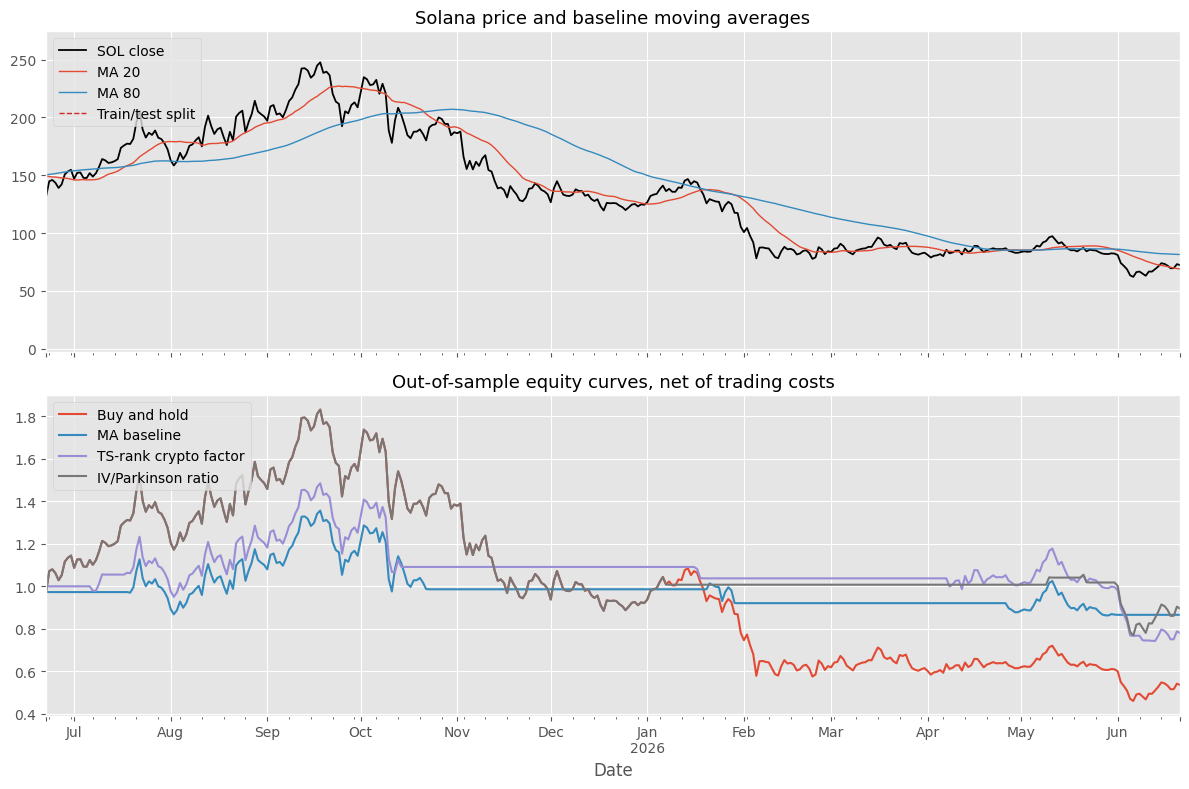

In [41]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

sol_close.plot(ax=axes[0], color="black", lw=1.3, label="SOL close")
ma_fast.plot(ax=axes[0], lw=1.0, label=f"MA {fast_window}")
ma_slow.plot(ax=axes[0], lw=1.0, label=f"MA {slow_window}")
axes[0].axvline(train_end, color="tab:red", ls="--", lw=1, label="Train/test split")
axes[0].set_title("Solana price and baseline moving averages")
axes[0].legend(loc="upper left")

equity_curve(buy_hold_returns.loc[test_mask]).plot(ax=axes[1], label="Buy and hold")
equity_curve(baseline_returns.loc[test_mask]).plot(ax=axes[1], label="MA baseline")
equity_curve(rank_returns.loc[test_mask]).plot(ax=axes[1], label="TS-rank crypto factor")
equity_curve(vol_ratio_returns.loc[test_mask]).plot(ax=axes[1], label="IV/Parkinson ratio")
axes[1].set_title("Out-of-sample equity curves, net of trading costs")
axes[1].legend(loc="upper left")
plt.tight_layout()
plt.show()

## 3. Adding Econometric, ML, and AI Agents

Features:

- Lagged returns: short-term autocorrelation and reversal effects.
- Momentum over 5, 10, and 20 days.
- Realized volatility over 10 and 20 days.
- RSI and moving-average distance.
- Volume z-score as a simple liquidity/attention proxy.

Target variable:

- `target_return`: next-day SOL return.
- `target_up`: whether the next-day return is positive.

Model validation:

- Models are fit on the train window only and evaluated on the final out-of-sample year.
- The econometric model is a rolling ridge-regularized AR model.
- The ML model is a logistic classifier implemented directly with numpy.
- The AI-agent model combines trend, econometric, ML, and risk-control agents.

In [42]:
def rsi(price: pd.Series, window: int = 14) -> pd.Series:
    delta = price.diff()
    gain = delta.clip(lower=0.0).rolling(window).mean()
    loss = (-delta.clip(upper=0.0)).rolling(window).mean()
    rs = gain / loss.replace(0.0, np.nan)
    return 100.0 - (100.0 / (1.0 + rs))


def build_single_asset_features(price: pd.Series, vol: pd.Series) -> pd.DataFrame:
    ret = price.pct_change()
    features = pd.DataFrame(index=price.index)

    # Lagged returns are the simplest econometric state variables.
    for lag in [1, 2, 3, 5]:
        features[f"ret_lag_{lag}"] = ret.shift(lag)

    # Momentum and volatility summarize recent trend and risk regimes.
    for window in [5, 10, 20]:
        features[f"mom_{window}"] = price.pct_change(window)
    for window in [10, 20]:
        features[f"vol_{window}"] = ret.rolling(window).std()

    features["rsi_14"] = rsi(price, 14)
    features["ma_gap_20_80"] = price.rolling(20).mean() / price.rolling(80).mean() - 1.0
    features["volume_z_20"] = (vol - vol.rolling(20).mean()) / vol.rolling(20).std()

    features["target_return"] = ret.shift(-1)
    features["target_up"] = (features["target_return"] > 0.0).astype(int)
    features = features.replace([np.inf, -np.inf], np.nan).dropna()
    return features


sol_features = build_single_asset_features(sol_close, volume[BASELINE_TICKER])
model_features = [
    "ret_lag_1", "ret_lag_2", "ret_lag_3", "ret_lag_5",
    "mom_5", "mom_10", "mom_20", "vol_10", "vol_20",
    "rsi_14", "ma_gap_20_80", "volume_z_20",
]

feature_train = sol_features.index <= train_end
feature_test = sol_features.index > train_end

print(f"Feature rows: {len(sol_features):,}")
print(f"Training feature rows: {feature_train.sum():,}")
print(f"Testing feature rows: {feature_test.sum():,}")
print(sol_features[model_features + ["target_return", "target_up"]].tail(3).round(4).to_string())

Feature rows: 1,188
Training feature rows: 824
Testing feature rows: 364
            ret_lag_1  ret_lag_2  ret_lag_3  ret_lag_5   mom_5  mom_10  mom_20  vol_10  vol_20   rsi_14  ma_gap_20_80  volume_z_20  target_return  target_up
Date                                                                                                                                                        
2026-06-18    -0.0202    -0.0076     0.0395     0.0318  0.0109  0.0424 -0.1502  0.0331  0.0398  51.5083       -0.1391      -0.6326         0.0014          1
2026-06-19    -0.0320    -0.0202    -0.0076     0.0333 -0.0203  0.0733 -0.1554  0.0312  0.0397  62.4938       -0.1452      -1.0132         0.0495          1
2026-06-20     0.0014    -0.0320    -0.0202     0.0395 -0.0109  0.1585 -0.1109  0.0310  0.0417  70.2621       -0.1497      -0.7830        -0.0103          0


In [43]:
def fit_ridge_regression(x: np.ndarray, y: np.ndarray, l2: float = 1e-4) -> np.ndarray:
    # Closed-form ridge regression with an unpenalized intercept.
    x_design = np.column_stack([np.ones(len(x)), x])
    penalty = np.eye(x_design.shape[1])
    penalty[0, 0] = 0.0
    lhs = x_design.T @ x_design + l2 * penalty
    rhs = x_design.T @ y
    return np.linalg.pinv(lhs) @ rhs


def rolling_econometric_forecast(
    features: pd.DataFrame,
    columns: list[str],
    window: int = 252,
    l2: float = 1e-4,
) -> pd.Series:
    # Walk-forward AR-style model. Each forecast uses only prior rows.
    x_all = features[columns].to_numpy(dtype=float)
    y_all = features["target_return"].to_numpy(dtype=float)
    preds = pd.Series(index=features.index, dtype=float)

    for i in range(window, len(features)):
        x_train = x_all[i - window : i]
        y_train = y_all[i - window : i]
        beta = fit_ridge_regression(x_train, y_train, l2=l2)
        x_now = np.r_[1.0, x_all[i]]
        preds.iloc[i] = float(x_now @ beta)
    return preds


econometric_columns = ["ret_lag_1", "ret_lag_2", "ret_lag_3", "mom_5", "mom_20", "vol_20"]
ar_pred = rolling_econometric_forecast(sol_features, econometric_columns, window=252, l2=1e-3)

# A model must clear trading costs plus a small uncertainty buffer to go long.
ar_signal = (ar_pred > COST_BPS / 10_000.0).astype(float)
ar_returns, ar_position, ar_turnover = strategy_returns_from_position(sol_close, ar_signal.reindex(sol_close.index))

In [44]:
def sigmoid(z: np.ndarray) -> np.ndarray:
    z = np.clip(z, -40.0, 40.0)
    return 1.0 / (1.0 + np.exp(-z))


@dataclass
class NumpyLogisticModel:
    mean: np.ndarray
    scale: np.ndarray
    weights: np.ndarray

    def predict_proba(self, x: pd.DataFrame) -> pd.Series:
        x_scaled = (x.to_numpy(dtype=float) - self.mean) / self.scale
        x_design = np.column_stack([np.ones(len(x_scaled)), x_scaled])
        proba = sigmoid(x_design @ self.weights)
        return pd.Series(proba, index=x.index, name="prob_up")


def fit_logistic_classifier(
    x: pd.DataFrame,
    y: pd.Series,
    learning_rate: float = 0.04,
    epochs: int = 2500,
    l2: float = 0.10,
) -> NumpyLogisticModel:
    # A compact logistic model keeps the notebook self-contained.
    x_values = x.to_numpy(dtype=float)
    y_values = y.to_numpy(dtype=float)
    mean = x_values.mean(axis=0)
    scale = x_values.std(axis=0)
    scale = np.where(scale == 0.0, 1.0, scale)
    x_scaled = (x_values - mean) / scale
    x_design = np.column_stack([np.ones(len(x_scaled)), x_scaled])
    weights = np.zeros(x_design.shape[1])

    for _ in range(epochs):
        probs = sigmoid(x_design @ weights)
        gradient = (x_design.T @ (probs - y_values)) / len(y_values)
        gradient[1:] += l2 * weights[1:] / len(y_values)
        weights -= learning_rate * gradient

    return NumpyLogisticModel(mean=mean, scale=scale, weights=weights)


X_train = sol_features.loc[feature_train, model_features]
y_train = sol_features.loc[feature_train, "target_up"]
logistic_model = fit_logistic_classifier(X_train, y_train)

ml_proba = logistic_model.predict_proba(sol_features[model_features])
ml_signal = (ml_proba > 0.53).astype(float)
ml_returns, ml_position, ml_turnover = strategy_returns_from_position(sol_close, ml_signal.reindex(sol_close.index))

test_direction_accuracy = (
    (ml_proba.loc[feature_test] > 0.5).astype(int)
    == sol_features.loc[feature_test, "target_up"]
).mean()
print(f"ML test directional accuracy: {test_direction_accuracy:.3f}")

ML test directional accuracy: 0.448


In [45]:
@dataclass
class AgentVote:
    name: str
    weight: float
    score: pd.Series


class RiskManagerAgent:
    def __init__(self, price: pd.Series, vol: pd.Series, train_end: pd.Timestamp):
        asset_ret = price.pct_change()
        ann_vol_20 = asset_ret.rolling(20).std() * math.sqrt(ANNUALIZATION)
        drawdown_60 = price / price.rolling(60).max() - 1.0
        volume_z = (vol - vol.rolling(20).mean()) / vol.rolling(20).std()

        # Thresholds are calibrated on training data only.
        self.high_vol_threshold = ann_vol_20.loc[:train_end].quantile(0.80)
        self.ann_vol_20 = ann_vol_20
        self.drawdown_60 = drawdown_60
        self.volume_z = volume_z

    def multiplier(self) -> pd.Series:
        multiplier = pd.Series(1.0, index=self.ann_vol_20.index)

        # Reduce exposure in high-volatility regimes instead of trying
        # to predict exact crash dates.
        multiplier[self.ann_vol_20 > self.high_vol_threshold] *= 0.50

        # A large local drawdown is treated as a circuit breaker.
        multiplier[self.drawdown_60 < -0.25] = 0.0

        # Very weak volume is a liquidity/participation warning.
        multiplier[self.volume_z < -1.5] *= 0.50
        return multiplier.fillna(0.0).clip(0.0, 1.0)


class MetaAllocationAgent:
    def __init__(self, votes: list[AgentVote], risk_multiplier: pd.Series, threshold: float = 0.55):
        self.votes = votes
        self.risk_multiplier = risk_multiplier
        self.threshold = threshold

    def position(self, index: pd.Index) -> pd.Series:
        total_weight = sum(v.weight for v in self.votes)
        score = pd.Series(0.0, index=index)
        for vote in self.votes:
            score += vote.weight * vote.score.reindex(index).ffill().fillna(0.0)
        score = score / total_weight

        raw_position = (score >= self.threshold).astype(float)
        risk = self.risk_multiplier.reindex(index).ffill().fillna(0.0)
        return (raw_position * risk).clip(0.0, 1.0)


# Convert ML probability to a bounded confidence score.
ml_score = ((ml_proba - 0.50) / 0.12 + 0.50).clip(0.0, 1.0)

votes = [
    AgentVote("trend_agent", 0.18, baseline_signal),
    AgentVote("rank_factor_agent", 0.17, rank_signal),
    AgentVote("vol_ratio_agent", 0.15, vol_ratio_signal),
    AgentVote("econometric_agent", 0.22, ar_signal),
    AgentVote("ml_agent", 0.28, ml_score),
]
risk_agent = RiskManagerAgent(sol_close, volume[BASELINE_TICKER], train_end)
meta_agent = MetaAllocationAgent(votes, risk_agent.multiplier(), threshold=0.55)

ai_agent_position_raw = meta_agent.position(sol_close.index)
ai_agent_returns, ai_agent_position, ai_agent_turnover = strategy_returns_from_position(sol_close, ai_agent_position_raw)

In [46]:
single_asset_metrics = {
    "Buy and Hold SOL": performance_metrics(
        buy_hold_returns.loc[test_mask], buy_hold_position.loc[test_mask], buy_hold_turnover.loc[test_mask]
    ),
    "MA Baseline": performance_metrics(
        baseline_returns.loc[test_mask], baseline_position.loc[test_mask], baseline_turnover.loc[test_mask]
    ),
    "TS-Rank Crypto Factor": performance_metrics(
        rank_returns.loc[test_mask], rank_position.loc[test_mask], rank_turnover.loc[test_mask]
    ),
    "IV/Parkinson Vol Ratio": performance_metrics(
        vol_ratio_returns.loc[test_mask], vol_ratio_position.loc[test_mask], vol_ratio_turnover.loc[test_mask]
    ),
    "Econometric AR": performance_metrics(
        ar_returns.loc[test_mask], ar_position.loc[test_mask], ar_turnover.loc[test_mask]
    ),
    "ML Logistic": performance_metrics(
        ml_returns.loc[test_mask], ml_position.loc[test_mask], ml_turnover.loc[test_mask]
    ),
    "AI Meta-Agent": performance_metrics(
        ai_agent_returns.loc[test_mask], ai_agent_position.loc[test_mask], ai_agent_turnover.loc[test_mask]
    ),
}
single_asset_table = print_metrics_table(single_asset_metrics, "Out-of-sample single-asset model comparison")

Out-of-sample single-asset model comparison
                           ROI  Returns  Sharpe  Drawdown  Turnover  Margin  Fitness
Buy and Hold SOL       -0.4642  -0.4642 -0.5013   -0.7489    0.0000     NaN  -0.9660
MA Baseline            -0.1343  -0.1343 -0.0829   -0.3641    0.0247 -0.0149  -0.0859
TS-Rank Crypto Factor  -0.2200  -0.2200 -0.2887   -0.4999    0.0466 -0.0129  -0.3830
IV/Parkinson Vol Ratio -0.1052  -0.1052  0.1074   -0.5806    0.0164 -0.0175   0.0985
Econometric AR         -0.4149  -0.4149 -0.7572   -0.6302    0.3205 -0.0035  -0.8614
ML Logistic            -0.4332  -0.4332 -1.1865   -0.5748    0.1973 -0.0060  -1.7582
AI Meta-Agent          -0.0238  -0.0238  0.1452   -0.3529    0.0932 -0.0007   0.0634


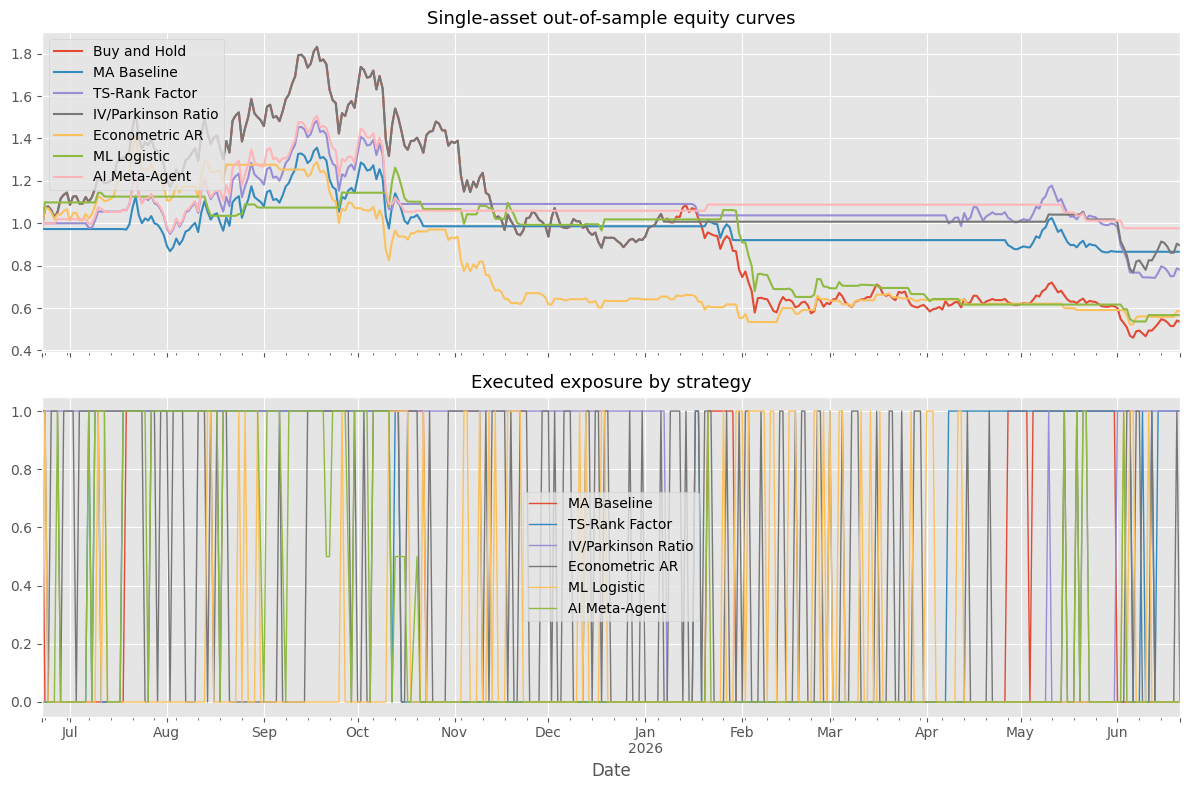

In [47]:
strategy_return_map = {
    "Buy and Hold": buy_hold_returns.loc[test_mask],
    "MA Baseline": baseline_returns.loc[test_mask],
    "TS-Rank Factor": rank_returns.loc[test_mask],
    "IV/Parkinson Ratio": vol_ratio_returns.loc[test_mask],
    "Econometric AR": ar_returns.loc[test_mask],
    "ML Logistic": ml_returns.loc[test_mask],
    "AI Meta-Agent": ai_agent_returns.loc[test_mask],
}

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
for name, strategy_ret in strategy_return_map.items():
    equity_curve(strategy_ret).plot(ax=axes[0], label=name)
axes[0].set_title("Single-asset out-of-sample equity curves")
axes[0].legend(loc="upper left")

pd.DataFrame({
    "MA Baseline": baseline_position.loc[test_mask],
    "TS-Rank Factor": rank_position.loc[test_mask],
    "IV/Parkinson Ratio": vol_ratio_position.loc[test_mask],
    "Econometric AR": ar_position.loc[test_mask],
    "ML Logistic": ml_position.loc[test_mask],
    "AI Meta-Agent": ai_agent_position.loc[test_mask],
}).plot(ax=axes[1], lw=1.0)
axes[1].set_title("Executed exposure by strategy")
axes[1].set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

### Random-Chance Check

To check whether the best agent result could plausibly come from random exposure timing, I compare its test Sharpe with randomized positions that preserve the same exposure distribution by circularly shifting the agent's executed positions. This is not a proof of alpha, but it is a useful sanity check against pure luck.

In [48]:
def circular_shift_randomization_test(
    price: pd.Series,
    observed_position: pd.Series,
    observed_returns: pd.Series,
    n_trials: int = 1000,
) -> tuple[float, pd.Series]:
    asset_return = price.pct_change().fillna(0.0).loc[observed_returns.index]
    position_values = observed_position.reindex(observed_returns.index).fillna(0.0).to_numpy()
    observed_sharpe = performance_metrics(observed_returns)["Sharpe"]

    random_sharpes = []
    for _ in range(n_trials):
        shift = int(rng.integers(1, len(position_values)))
        shifted_position = np.roll(position_values, shift)
        shifted_turnover = np.abs(np.diff(np.r_[0.0, shifted_position]))
        shifted_returns = shifted_position * asset_return.to_numpy() - shifted_turnover * COST_BPS / 10_000.0
        random_sharpes.append(performance_metrics(pd.Series(shifted_returns, index=asset_return.index))["Sharpe"])

    random_sharpes = pd.Series(random_sharpes, name="Randomized Sharpe")
    p_value = float((random_sharpes >= observed_sharpe).mean())
    return p_value, random_sharpes


p_value, random_sharpes = circular_shift_randomization_test(
    sol_close,
    ai_agent_position.loc[test_mask],
    ai_agent_returns.loc[test_mask],
    n_trials=1000,
)
print(f"Randomized-position p-value for AI Meta-Agent Sharpe: {p_value:.3f}")
print(random_sharpes.describe(percentiles=[0.05, 0.5, 0.95]).round(4).to_string())

Randomized-position p-value for AI Meta-Agent Sharpe: 0.310
count    1000.0000
mean       -0.3127
std         0.8893
min        -2.2930
5%         -1.6704
50%        -0.4260
95%         1.2026
max         2.1839


## 4. Static Portfolio Management on Historical Data

I use seven popular coins (rating top at kaiso): BTC, ETH, SOL, XRP, ADA, DOGE, and LINK. Expected returns and covariance are estimated on the one-year window before the out-of-sample test year. Assuming the optimal portfolio as long-only with a 40 percent single-asset cap.

In [49]:
portfolio_returns = returns[PORTFOLIO_TICKERS]
estimation_returns = portfolio_returns.loc[(portfolio_returns.index > estimation_start) & (portfolio_returns.index <= train_end)]
test_portfolio_returns = portfolio_returns.loc[portfolio_returns.index > train_end]

mu_annual = estimation_returns.mean() * ANNUALIZATION
cov_annual = estimation_returns.cov() * ANNUALIZATION

print(f"Portfolio estimation window: {estimation_returns.index.min().date()} to {estimation_returns.index.max().date()}")
print(f"Portfolio test window: {test_portfolio_returns.index.min().date()} to {test_portfolio_returns.index.max().date()}")
print("Annualized train-window expected returns")
print(mu_annual.round(3).to_string())

Portfolio estimation window: 2024-06-22 to 2025-06-21
Portfolio test window: 2025-06-22 to 2026-06-21
Annualized train-window expected returns
Ticker
BTC-USD     0.591
ETH-USD    -0.155
SOL-USD     0.381
XRP-USD     1.903
ADA-USD     0.978
DOGE-USD    0.703
LINK-USD    0.326


In [50]:
def cap_and_renormalize(weights: pd.Series, max_weight: float = 0.40) -> pd.Series:
    # Reallocate excess weight among uncapped names until the cap is respected.
    weights = weights.clip(lower=0.0).astype(float)
    if weights.sum() == 0.0:
        return pd.Series(1.0 / len(weights), index=weights.index)
    weights = weights / weights.sum()
    capped = pd.Series(0.0, index=weights.index)
    free = pd.Series(True, index=weights.index)
    remaining = 1.0

    while free.any():
        free_weights = weights[free]
        allocation = free_weights / free_weights.sum() * remaining
        over_cap = allocation > max_weight
        if not over_cap.any():
            capped[free] = allocation
            break
        capped[allocation[over_cap].index] = max_weight
        free[allocation[over_cap].index] = False
        remaining = 1.0 - capped.sum()
    return capped


def optimize_static_portfolio(mu: pd.Series, cov: pd.DataFrame, objective: str, max_weight: float = 0.40) -> pd.Series:
    n_assets = len(mu)
    cov_values = cov.to_numpy()
    mu_values = mu.to_numpy()

    def portfolio_vol(w: np.ndarray) -> float:
        return float(np.sqrt(max(w @ cov_values @ w, 1e-12)))

    # Draw many feasible capped long-only portfolios. This avoids a
    # compiled optimizer dependency and is stable for a seven-asset MVP.
    candidates: list[np.ndarray] = [np.ones(n_assets) / n_assets]
    attempts = 0
    while len(candidates) < 20_000 and attempts < 200_000:
        attempts += 1
        candidate = rng.dirichlet(np.ones(n_assets))
        if candidate.max() <= max_weight + 1e-12:
            candidates.append(candidate)

    candidate_matrix = np.vstack(candidates)
    vols = np.sqrt(np.maximum(np.einsum("ij,jk,ik->i", candidate_matrix, cov_values, candidate_matrix), 1e-12))
    rets = candidate_matrix @ mu_values

    if objective == "max_sharpe":
        best_idx = int(np.nanargmax(rets / vols))
    elif objective == "min_vol":
        best_idx = int(np.nanargmin(vols))
    else:
        raise ValueError(f"Unknown objective: {objective}")
    return pd.Series(candidate_matrix[best_idx], index=mu.index)


def inverse_vol_weights(cov: pd.DataFrame, max_weight: float = 0.40) -> pd.Series:
    vols = pd.Series(np.sqrt(np.diag(cov)), index=cov.index)
    raw = 1.0 / vols.replace(0.0, np.nan)
    return cap_and_renormalize(raw.fillna(0.0), max_weight=max_weight)


equal_weights = pd.Series(1.0 / len(PORTFOLIO_TICKERS), index=PORTFOLIO_TICKERS)
min_vol_weights = optimize_static_portfolio(mu_annual, cov_annual, "min_vol", max_weight=0.40)
max_sharpe_weights = optimize_static_portfolio(mu_annual, cov_annual, "max_sharpe", max_weight=0.40)
inv_vol_weights = inverse_vol_weights(cov_annual, max_weight=0.40)

weights_table = pd.DataFrame({
    "Equal": equal_weights,
    "InverseVol": inv_vol_weights,
    "MinVol": min_vol_weights,
    "MaxSharpe": max_sharpe_weights,
}).round(4)
print("Static portfolio weights")
print(weights_table.to_string())

Static portfolio weights
           Equal  InverseVol  MinVol  MaxSharpe
BTC-USD   0.1429      0.2383  0.3935     0.3438
ETH-USD   0.1429      0.1612  0.3731     0.0222
SOL-USD   0.1429      0.1365  0.1216     0.1280
XRP-USD   0.1429      0.1207  0.0461     0.3929
ADA-USD   0.1429      0.1029  0.0370     0.0471
DOGE-USD  0.1429      0.1194  0.0202     0.0376
LINK-USD  0.1429      0.1210  0.0084     0.0284


Out-of-sample static portfolio metrics
               ROI  Returns  Sharpe  Drawdown  Turnover  Margin  Fitness
Equal      -0.4407  -0.4407 -0.5746   -0.6917    0.0027 -0.4407  -1.0789
InverseVol -0.4172  -0.4172 -0.5711   -0.6668    0.0027 -0.4172  -1.0434
MinVol     -0.3568  -0.3568 -0.5077   -0.6247    0.0027 -0.3568  -0.8578
MaxSharpe  -0.4247  -0.4247 -0.6801   -0.6310    0.0027 -0.4247  -1.2536


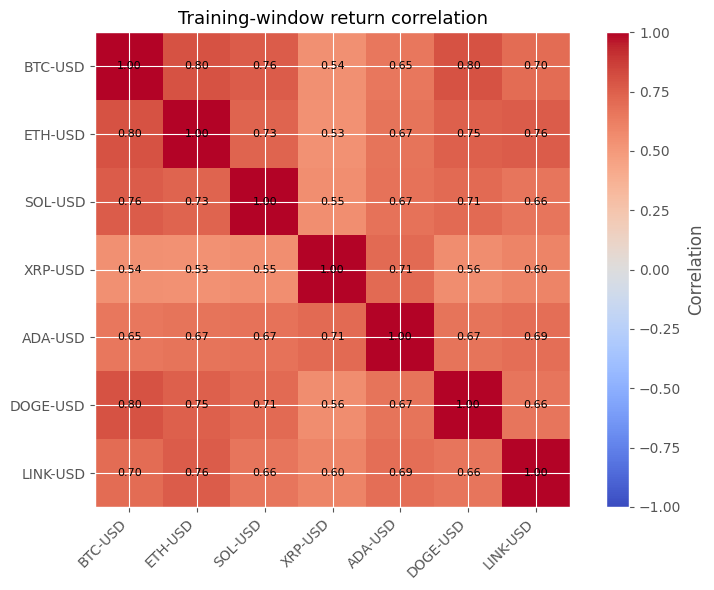

In [51]:
def static_portfolio_returns(test_returns: pd.DataFrame, weights: pd.Series, cost_bps: float = COST_BPS) -> tuple[pd.Series, pd.Series]:
    aligned_weights = weights.reindex(test_returns.columns).fillna(0.0)
    gross = test_returns @ aligned_weights
    turnover = pd.Series(0.0, index=test_returns.index)
    turnover.iloc[0] = aligned_weights.abs().sum()
    net = gross - turnover * cost_bps / 10_000.0
    return net, turnover


static_candidates = {
    "Equal": equal_weights,
    "InverseVol": inv_vol_weights,
    "MinVol": min_vol_weights,
    "MaxSharpe": max_sharpe_weights,
}

static_metric_map = {}
static_return_map = {}
for name, weights in static_candidates.items():
    port_ret, port_turnover = static_portfolio_returns(test_portfolio_returns, weights)
    static_return_map[name] = port_ret
    static_metric_map[name] = performance_metrics(
        port_ret,
        position=pd.Series(weights.sum(), index=port_ret.index),
        turnover=port_turnover,
    )

static_table = print_metrics_table(static_metric_map, "Out-of-sample static portfolio metrics")

correlation = estimation_returns.corr()
fig, ax = plt.subplots(figsize=(8, 6))
image = ax.imshow(correlation.to_numpy(), cmap="coolwarm", vmin=-1.0, vmax=1.0)
ax.set_xticks(range(len(correlation.columns)))
ax.set_yticks(range(len(correlation.index)))
ax.set_xticklabels(correlation.columns, rotation=45, ha="right")
ax.set_yticklabels(correlation.index)
for row in range(len(correlation.index)):
    for col in range(len(correlation.columns)):
        ax.text(col, row, f"{correlation.iloc[row, col]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(image, ax=ax, label="Correlation")
ax.set_title("Training-window return correlation")
plt.tight_layout()
plt.show()

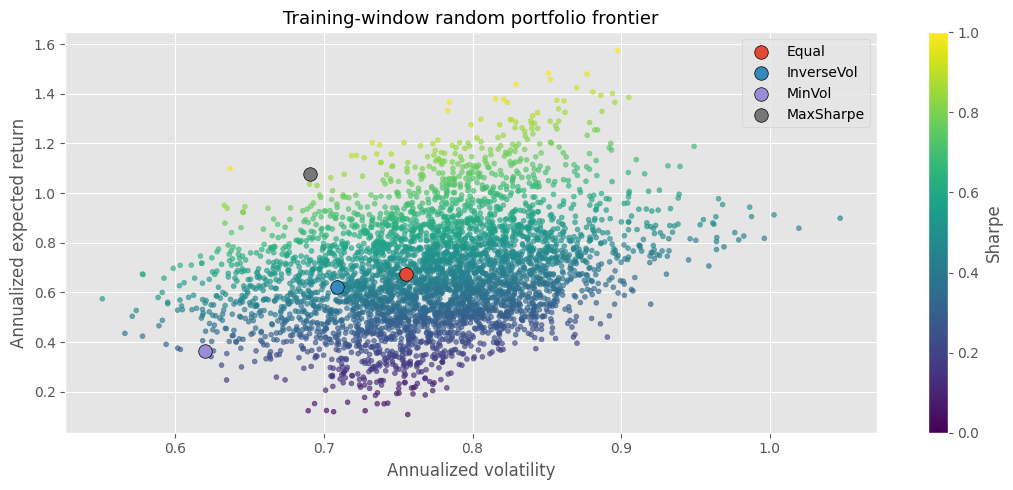

In [52]:
random_weights = rng.dirichlet(np.ones(len(PORTFOLIO_TICKERS)), size=4000)
random_returns = random_weights @ mu_annual.to_numpy()
random_vols = np.sqrt(np.einsum("ij,jk,ik->i", random_weights, cov_annual.to_numpy(), random_weights))
random_sharpes = random_returns / random_vols

plt.figure(figsize=(11, 5))
plt.scatter(random_vols, random_returns, c=random_sharpes, s=12, cmap="viridis", alpha=0.65)
for name, weights in static_candidates.items():
    w = weights.to_numpy()
    vol = np.sqrt(w @ cov_annual.to_numpy() @ w)
    ret = w @ mu_annual.to_numpy()
    plt.scatter(vol, ret, s=95, edgecolor="black", label=name)
plt.colorbar(label="Sharpe")
plt.xlabel("Annualized volatility")
plt.ylabel("Annualized expected return")
plt.title("Training-window random portfolio frontier")
plt.legend()
plt.tight_layout()
plt.show()

Real-trading application: the static optimizer provides a transparent base allocation. In production, I would apply exchange liquidity filters, maximum order-size constraints, and post-trade risk checks before sending orders. The max-Sharpe portfolio is the nominal optimal portfolio here, while min-vol and inverse-vol are useful fallback allocations during unstable regimes.

## 5. Dynamic Portfolio Rebalancing for the Small Portfolio

Dynamic logic:

- Estimate trailing 63-day and 21-day momentum.
- Penalize high trailing volatility.
- Cap each coin at 35 percent.
- Reduce total risky gross exposure when market volatility is above the training-window 75th percentile.
- Compare monthly rebalancing with an adaptive rule that can also rebalance when target weights drift materially.

The most effective rebalancing policy is selected using out-of-sample Sharpe, with drawdown checked as a hard risk sanity constraint.

In [53]:
def cap_with_cash(scores: pd.Series, max_weight: float = 0.35, target_gross: float = 1.0) -> pd.Series:
    # Scores become risky weights; leftover gross is held as cash earning zero.
    scores = scores.replace([np.inf, -np.inf], np.nan).fillna(0.0).clip(lower=0.0)
    if scores.sum() <= 0.0 or target_gross <= 0.0:
        return pd.Series(0.0, index=scores.index)

    capped = pd.Series(0.0, index=scores.index)
    free = pd.Series(True, index=scores.index)
    remaining = min(target_gross, 1.0)

    while free.any() and remaining > 1e-12:
        free_scores = scores[free]
        if free_scores.sum() <= 0.0:
            break
        allocation = free_scores / free_scores.sum() * remaining
        over_cap = allocation > max_weight
        if not over_cap.any():
            capped[free] = allocation
            break
        capped[allocation[over_cap].index] = max_weight
        free[allocation[over_cap].index] = False
        remaining = min(target_gross, 1.0) - capped.sum()
    return capped.clip(0.0, max_weight)


market_train_vol = estimation_returns.mean(axis=1).rolling(21).std() * math.sqrt(ANNUALIZATION)
high_market_vol_threshold = market_train_vol.quantile(0.75)


def target_dynamic_weights(date: pd.Timestamp) -> pd.Series:
    hist_prices = close.loc[:date, PORTFOLIO_TICKERS]
    hist_returns = portfolio_returns.loc[:date, PORTFOLIO_TICKERS]
    if len(hist_returns) < 120:
        return pd.Series(0.0, index=PORTFOLIO_TICKERS)

    mom_63 = hist_prices.pct_change(63).iloc[-1]
    mom_21 = hist_prices.pct_change(21).iloc[-1]
    vol_21 = hist_returns.rolling(21).std().iloc[-1] * math.sqrt(ANNUALIZATION)

    # Blend medium and short momentum, then divide by risk.
    raw_momentum = 0.70 * mom_63 + 0.30 * mom_21
    scores = raw_momentum.clip(lower=0.0) / vol_21.replace(0.0, np.nan)

    market_vol = hist_returns.mean(axis=1).rolling(21).std().iloc[-1] * math.sqrt(ANNUALIZATION)
    target_gross = 0.65 if market_vol > high_market_vol_threshold else 1.0
    return cap_with_cash(scores, max_weight=0.35, target_gross=target_gross)


def run_dynamic_rebalancer(mode: str) -> tuple[pd.Series, pd.DataFrame, pd.Series, list[pd.Timestamp]]:
    weights = pd.DataFrame(0.0, index=portfolio_returns.index, columns=PORTFOLIO_TICKERS)
    current_weights = pd.Series(0.0, index=PORTFOLIO_TICKERS)
    last_rebalance: pd.Timestamp | None = None
    rebalance_dates: list[pd.Timestamp] = []

    for date in portfolio_returns.index:
        if date <= train_end:
            weights.loc[date] = current_weights
            continue

        target = target_dynamic_weights(date)
        month_changed = last_rebalance is None or date.month != last_rebalance.month or date.year != last_rebalance.year
        weight_deviation = float((target - current_weights).abs().sum())

        if mode == "monthly":
            should_rebalance = month_changed
        elif mode == "adaptive":
            should_rebalance = month_changed or weight_deviation > 0.25
        else:
            raise ValueError("mode must be monthly or adaptive")

        if should_rebalance:
            current_weights = target
            last_rebalance = date
            rebalance_dates.append(date)

        weights.loc[date] = current_weights

    executed_weights = weights.shift(1).fillna(0.0)
    turnover = weights.diff().abs().sum(axis=1).fillna(weights.abs().sum(axis=1))
    gross_returns = (executed_weights * portfolio_returns[PORTFOLIO_TICKERS]).sum(axis=1)
    net_returns = gross_returns - turnover * COST_BPS / 10_000.0
    test_index = portfolio_returns.index > train_end
    return net_returns.loc[test_index], executed_weights.loc[test_index], turnover.loc[test_index], rebalance_dates


monthly_returns, monthly_weights, monthly_turnover, monthly_dates = run_dynamic_rebalancer("monthly")
adaptive_returns, adaptive_weights, adaptive_turnover, adaptive_dates = run_dynamic_rebalancer("adaptive")

dynamic_metric_map = dict(static_metric_map)
dynamic_metric_map["Dynamic Monthly"] = performance_metrics(
    monthly_returns,
    position=monthly_weights.sum(axis=1),
    turnover=monthly_turnover,
)
dynamic_metric_map["Dynamic Adaptive"] = performance_metrics(
    adaptive_returns,
    position=adaptive_weights.sum(axis=1),
    turnover=adaptive_turnover,
)
dynamic_table = print_metrics_table(dynamic_metric_map, "Static vs dynamic portfolio metrics")

chosen_policy = dynamic_table.sort_values("Sharpe", ascending=False).index[0]
print(f"Selected policy by out-of-sample Sharpe: {chosen_policy}")
print(f"Monthly rebalances: {len(monthly_dates)}")
print(f"Adaptive rebalances: {len(adaptive_dates)}")

Static vs dynamic portfolio metrics
                     ROI  Returns  Sharpe  Drawdown  Turnover  Margin  Fitness
Equal            -0.4407  -0.4407 -0.5746   -0.6917    0.0027 -0.4407  -1.0789
InverseVol       -0.4172  -0.4172 -0.5711   -0.6668    0.0027 -0.4172  -1.0434
MinVol           -0.3568  -0.3568 -0.5077   -0.6247    0.0027 -0.3568  -0.8578
MaxSharpe        -0.4247  -0.4247 -0.6801   -0.6310    0.0027 -0.4247  -1.2536
Dynamic Monthly  -0.1421  -0.1421 -0.1973   -0.4473    0.0151 -0.0257  -0.2104
Dynamic Adaptive -0.0951  -0.0951 -0.0466   -0.4649    0.0747 -0.0035  -0.0407
Selected policy by out-of-sample Sharpe: Dynamic Adaptive
Monthly rebalances: 13
Adaptive rebalances: 72


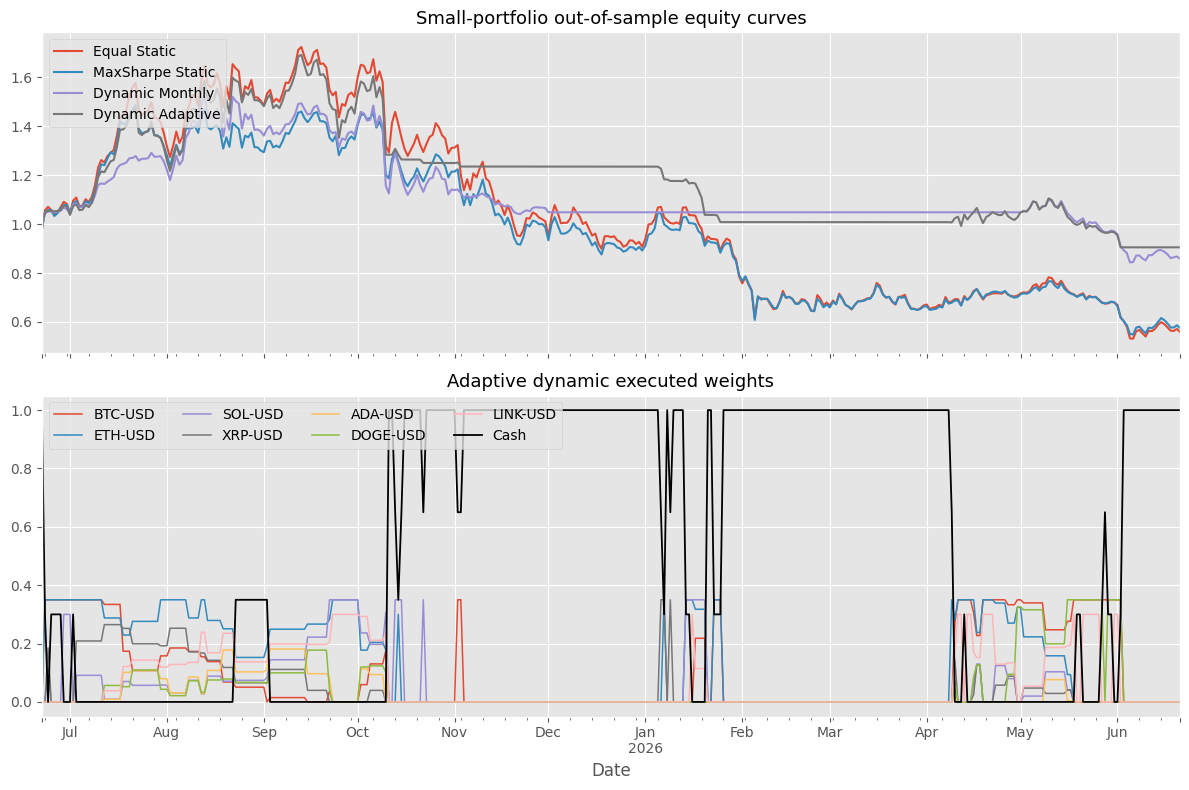

In [54]:
portfolio_equity = {
    "Equal Static": static_return_map["Equal"],
    "MaxSharpe Static": static_return_map["MaxSharpe"],
    "Dynamic Monthly": monthly_returns,
    "Dynamic Adaptive": adaptive_returns,
}

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
for name, ret in portfolio_equity.items():
    equity_curve(ret).plot(ax=axes[0], label=name)
axes[0].set_title("Small-portfolio out-of-sample equity curves")
axes[0].legend(loc="upper left")

adaptive_weights.plot(ax=axes[1], lw=1.1)
cash_weight = 1.0 - adaptive_weights.sum(axis=1)
cash_weight.plot(ax=axes[1], color="black", lw=1.3, label="Cash")
axes[1].set_title("Adaptive dynamic executed weights")
axes[1].set_ylim(-0.05, 1.05)
axes[1].legend(loc="upper left", ncol=4)
plt.tight_layout()
plt.show()

## 6. Expanded Dynamic Portfolio Across Multiple Coins

This final coding section implements the previously deferred multi-coin dynamic portfolio. It starts from every cryptocurrency ticker available in the local OHLCV snapshot, then applies a strict eligibility gate before trading:

- at least 252 raw observations before the training cutoff,
- at least 95 percent raw coverage during the out-of-sample test window,
- an actual raw quote on the final snapshot date,
- no stablecoin cash proxies in the risky alpha book, because cash is modelled separately.

The raw-data filter is important because forward-filled prices are useful for small missing feed gaps, but they must not turn a stale delisted or unavailable coin into a tradable asset. The allocation itself is long-only, uses no leverage, caps each coin at 20 percent, and leaves unused capital in cash.


In [55]:
expanded_data_summary = raw.groupby("Ticker").agg(
    rows=("Date", "size"),
    first_date=("Date", "min"),
    last_date=("Date", "max"),
)

expanded_test_dates = all_close.index[all_close.index > train_end]
required_last_date = all_close.index.max()
eligibility_rows = []

for ticker in available_expanded_tickers:
    ticker_dates = raw.loc[raw["Ticker"].eq(ticker), "Date"].sort_values()
    train_observations = int((ticker_dates <= train_end).sum())
    test_observations = int((ticker_dates > train_end).sum())
    test_coverage = test_observations / max(len(expanded_test_dates), 1)
    last_raw_date = ticker_dates.max()

    # A current raw quote is required; forward-filled prices alone are not accepted.
    has_current_raw_quote = bool(last_raw_date >= required_last_date)
    is_data_eligible = train_observations >= 252 and test_coverage >= 0.95 and has_current_raw_quote
    is_excluded_cash_proxy = ticker in EXCLUDED_EXPANDED_TICKERS
    is_eligible = is_data_eligible and not is_excluded_cash_proxy

    if is_excluded_cash_proxy:
        reason = "excluded_stablecoin"
    elif is_eligible:
        reason = "eligible"
    elif train_observations < 252:
        reason = "short_train_history"
    elif test_coverage < 0.95:
        reason = "low_test_coverage"
    else:
        reason = "stale_final_quote"

    eligibility_rows.append({
        "Ticker": ticker,
        "RawRows": int(len(ticker_dates)),
        "FirstDate": ticker_dates.min().date(),
        "LastRawDate": last_raw_date.date(),
        "TrainObs": train_observations,
        "TestCoverage": test_coverage,
        "CurrentQuote": has_current_raw_quote,
        "Status": reason,
    })

expanded_eligibility = pd.DataFrame(eligibility_rows).set_index("Ticker")
eligible_expanded_tickers = expanded_eligibility.index[expanded_eligibility["Status"].eq("eligible")].tolist()

if len(eligible_expanded_tickers) < 100:
    raise ValueError("The expanded dynamic portfolio needs at least 100 eligible non-stable crypto pairs.")

expanded_close = all_close[eligible_expanded_tickers].loc[close.index].dropna(how="any")
expanded_volume = all_volume[eligible_expanded_tickers].reindex(expanded_close.index).ffill()
expanded_returns = expanded_close.pct_change(fill_method=None).dropna(how="any")
expanded_test_returns = expanded_returns.loc[expanded_returns.index > train_end].fillna(0.0)

rejected_expanded = expanded_eligibility.loc[~expanded_eligibility["Status"].eq("eligible")]
print("Expanded-universe raw-data eligibility counts")
print(expanded_eligibility["Status"].value_counts().to_string())
print(f"Eligible expanded universe ({len(eligible_expanded_tickers)} non-stable coins): {', '.join(eligible_expanded_tickers)}")
if not rejected_expanded.empty:
    print("Rejected expanded candidates")
    print(rejected_expanded[["RawRows", "FirstDate", "LastRawDate", "TestCoverage", "CurrentQuote", "Status"]].to_string())
print(f"Expanded test window: {expanded_test_returns.index.min().date()} to {expanded_test_returns.index.max().date()}")


Expanded-universe raw-data eligibility counts
eligible               119
low_test_coverage        8
excluded_stablecoin      7
stale_final_quote        1
Eligible expanded universe (119 non-stable coins): 1INCH-USD, AAVE-USD, ADA-USD, AERO-USD, AIOZ-USD, AKT-USD, ALGO-USD, ANKR-USD, APE-USD, AR-USD, ARB-USD, ASTR-USD, ATOM-USD, AUDIO-USD, AVAX-USD, AXS-USD, BAL-USD, BAND-USD, BAT-USD, BCH-USD, BLUR-USD, BNB-USD, BONK-USD, BTC-USD, CAKE-USD, CELO-USD, CELR-USD, CFX-USD, CHZ-USD, CKB-USD, COTI-USD, CRO-USD, CRV-USD, DASH-USD, DOGE-USD, DOT-USD, DYDX-USD, EGLD-USD, ENJ-USD, ENS-USD, EOS-USD, ETC-USD, ETH-USD, ETHFI-USD, FET-USD, FIL-USD, FLOKI-USD, FLOW-USD, GLM-USD, GT-USD, HBAR-USD, HNT-USD, HOT-USD, ICP-USD, INJ-USD, IOTA-USD, IOTX-USD, JASMY-USD, JTO-USD, JUP-USD, KAS-USD, KAVA-USD, KCS-USD, KSM-USD, LDO-USD, LEO-USD, LINK-USD, LPT-USD, LRC-USD, LTC-USD, LUNC-USD, MANA-USD, MINA-USD, MKR-USD, NEAR-USD, NKN-USD, OKB-USD, OMG-USD, ONDO-USD, OP-USD, PENDLE-USD, PYTH-USD, QNT-USD, QTUM-US

In [56]:
expanded_train_returns = expanded_returns.loc[(expanded_returns.index > estimation_start) & (expanded_returns.index <= train_end)]
expanded_market_train_vol = expanded_train_returns.mean(axis=1).rolling(21).std() * math.sqrt(ANNUALIZATION)
expanded_high_market_vol_threshold = expanded_market_train_vol.quantile(0.75)


def expanded_target_weights(date: pd.Timestamp) -> pd.Series:
    hist_prices = expanded_close.loc[:date, eligible_expanded_tickers]
    hist_returns = expanded_returns.loc[:date, eligible_expanded_tickers]
    hist_volume = expanded_volume.loc[:date, eligible_expanded_tickers]
    if len(hist_returns) < 140:
        return pd.Series(0.0, index=eligible_expanded_tickers)

    current_prices = hist_prices.iloc[-1]
    mom_90 = current_prices / hist_prices.shift(90).iloc[-1] - 1.0
    mom_30 = current_prices / hist_prices.shift(30).iloc[-1] - 1.0
    vol_30 = hist_returns.rolling(30).std().iloc[-1] * math.sqrt(ANNUALIZATION)

    dollar_volume_30 = (hist_prices * hist_volume).rolling(30).mean().iloc[-1]
    liquidity_rank = dollar_volume_30.rank(pct=True).fillna(0.0)
    drawdown_90 = current_prices / hist_prices.rolling(90).max().iloc[-1] - 1.0

    # The signal favors positive medium-term momentum, confirms it with shorter
    # momentum, penalizes volatility, and gives liquid coins more capacity.
    raw_momentum = 0.65 * mom_90 + 0.35 * mom_30
    risk_adjusted_momentum = raw_momentum.clip(lower=0.0) / vol_30.replace(0.0, np.nan)
    scores = risk_adjusted_momentum * (0.50 + 0.50 * liquidity_rank)
    scores = scores.replace([np.inf, -np.inf], np.nan).fillna(0.0)

    # Severe 90-day drawdown names are skipped even if their short bounce is strong.
    scores = scores.where(drawdown_90 > -0.45, 0.0)
    selected_scores = scores[scores > 0.0].sort_values(ascending=False).head(min(8, len(scores)))
    filtered_scores = pd.Series(0.0, index=eligible_expanded_tickers)
    filtered_scores.loc[selected_scores.index] = selected_scores

    market_vol = hist_returns.mean(axis=1).rolling(21).std().iloc[-1] * math.sqrt(ANNUALIZATION)
    high_vol_regime = pd.notna(market_vol) and market_vol > expanded_high_market_vol_threshold
    target_gross = 0.70 if high_vol_regime else 1.0
    return cap_with_cash(filtered_scores, max_weight=0.20, target_gross=target_gross)


def run_expanded_dynamic_rebalancer(mode: str) -> tuple[pd.Series, pd.DataFrame, pd.Series, list[pd.Timestamp]]:
    weights = pd.DataFrame(0.0, index=expanded_returns.index, columns=eligible_expanded_tickers)
    current_weights = pd.Series(0.0, index=eligible_expanded_tickers)
    last_rebalance: pd.Timestamp | None = None
    rebalance_dates: list[pd.Timestamp] = []

    for date in expanded_returns.index:
        if date <= train_end:
            weights.loc[date] = current_weights
            continue

        target = expanded_target_weights(date)
        days_since_rebalance = np.inf if last_rebalance is None else (date - last_rebalance).days
        weekly_clock = days_since_rebalance >= 7
        weight_deviation = float((target - current_weights).abs().sum())

        if mode == "weekly":
            should_rebalance = weekly_clock
        elif mode == "adaptive":
            # Adaptive mode can trade sooner when the desired allocation has moved a lot.
            should_rebalance = weekly_clock or (days_since_rebalance >= 2 and weight_deviation > 0.20)
        else:
            raise ValueError("mode must be weekly or adaptive")

        if should_rebalance:
            current_weights = target
            last_rebalance = date
            rebalance_dates.append(date)

        weights.loc[date] = current_weights

    executed_weights = weights.shift(1).fillna(0.0)
    turnover = weights.diff().abs().sum(axis=1).fillna(weights.abs().sum(axis=1))
    gross_returns = (executed_weights * expanded_returns[eligible_expanded_tickers]).sum(axis=1, min_count=1).fillna(0.0)
    net_returns = gross_returns - turnover * COST_BPS / 10_000.0
    test_index = expanded_returns.index > train_end
    return net_returns.loc[test_index], executed_weights.loc[test_index], turnover.loc[test_index], rebalance_dates


expanded_equal_weights = pd.Series(1.0 / len(eligible_expanded_tickers), index=eligible_expanded_tickers)
expanded_equal_returns, expanded_equal_turnover = static_portfolio_returns(expanded_test_returns, expanded_equal_weights)
expanded_weekly_returns, expanded_weekly_weights, expanded_weekly_turnover, expanded_weekly_dates = run_expanded_dynamic_rebalancer("weekly")
expanded_adaptive_returns, expanded_adaptive_weights, expanded_adaptive_turnover, expanded_adaptive_dates = run_expanded_dynamic_rebalancer("adaptive")

expanded_metric_map = {
    "Expanded Equal Static": performance_metrics(
        expanded_equal_returns,
        position=pd.Series(1.0, index=expanded_equal_returns.index),
        turnover=expanded_equal_turnover,
    ),
    "Expanded Weekly Dynamic": performance_metrics(
        expanded_weekly_returns,
        position=expanded_weekly_weights.sum(axis=1),
        turnover=expanded_weekly_turnover,
    ),
    "Expanded Adaptive Dynamic": performance_metrics(
        expanded_adaptive_returns,
        position=expanded_adaptive_weights.sum(axis=1),
        turnover=expanded_adaptive_turnover,
    ),
}

expanded_dynamic_table = print_metrics_table(expanded_metric_map, "Expanded-universe portfolio metrics")

expanded_cash_weight = 1.0 - expanded_adaptive_weights.sum(axis=1)
expanded_weight_distribution = pd.DataFrame({
    "AverageWeight": expanded_adaptive_weights.mean(),
    "FinalWeight": expanded_adaptive_weights.iloc[-1],
    "MaxWeight": expanded_adaptive_weights.max(),
}).sort_values("AverageWeight", ascending=False)
expanded_weight_distribution.loc["Cash"] = [
    float(expanded_cash_weight.mean()),
    float(expanded_cash_weight.iloc[-1]),
    float(expanded_cash_weight.max()),
]

print(f"Weekly expanded rebalances: {len(expanded_weekly_dates)}")
print(f"Adaptive expanded rebalances: {len(expanded_adaptive_dates)}")
expanded_weight_distribution_display = pd.concat([
    expanded_weight_distribution.drop(index="Cash", errors="ignore").head(25),
    expanded_weight_distribution.loc[["Cash"]],
])
print("Expanded adaptive weight distribution, top 25 plus cash")
print(expanded_weight_distribution_display.round(4).to_string())


Expanded-universe portfolio metrics
                              ROI  Returns  Sharpe  Drawdown  Turnover  Margin  Fitness
Expanded Equal Static      0.8707   0.8707  1.1688   -0.5594    0.0027  0.8707   3.0848
Expanded Weekly Dynamic   -0.0123  -0.0123  0.4124   -0.5044    0.0785 -0.0004   0.1292
Expanded Adaptive Dynamic -0.0925  -0.0925  0.3261   -0.5775    0.1476 -0.0017   0.2581
Weekly expanded rebalances: 53
Adaptive expanded rebalances: 147
Expanded adaptive weight distribution, top 25 plus cash
           AverageWeight  FinalWeight  MaxWeight
ZEC-USD           0.0723       0.1020     0.2000
TRX-USD           0.0678       0.0000     0.2000
XMR-USD           0.0601       0.0000     0.2000
BCH-USD           0.0502       0.0000     0.2000
LEO-USD           0.0488       0.0000     0.2000
ETH-USD           0.0436       0.0000     0.2000
BNB-USD           0.0428       0.0000     0.2000
STRK-USD          0.0427       0.0000     0.2000
CHZ-USD           0.0413       0.0000     0.2000
O

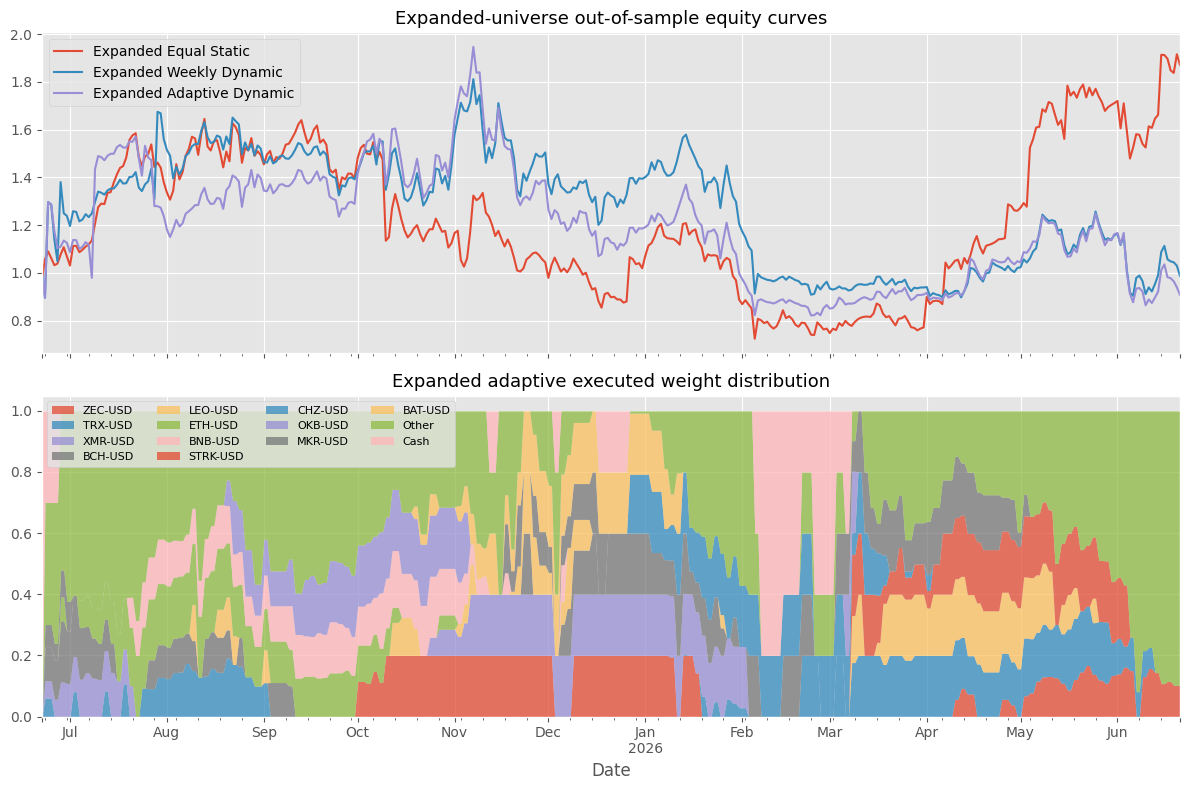

In [57]:
expanded_equity_map = {
    "Expanded Equal Static": expanded_equal_returns,
    "Expanded Weekly Dynamic": expanded_weekly_returns,
    "Expanded Adaptive Dynamic": expanded_adaptive_returns,
}

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
for name, ret in expanded_equity_map.items():
    equity_curve(ret).plot(ax=axes[0], label=name)
axes[0].set_title("Expanded-universe out-of-sample equity curves")
axes[0].legend(loc="upper left")

# Plot the most-used names and aggregate the rest so the chart remains readable.
top_weight_names = expanded_weight_distribution.drop(index="Cash", errors="ignore").head(12).index.tolist()
expanded_weight_plot = expanded_adaptive_weights[top_weight_names].copy()
other_weight = (expanded_adaptive_weights.drop(columns=top_weight_names, errors="ignore").sum(axis=1)).clip(lower=0.0)
if other_weight.max() > 1e-12:
    expanded_weight_plot["Other"] = other_weight
expanded_weight_plot["Cash"] = expanded_cash_weight.clip(lower=0.0)
expanded_weight_plot.plot.area(ax=axes[1], stacked=True, alpha=0.75, linewidth=0.0)
axes[1].set_title("Expanded adaptive executed weight distribution")
axes[1].set_ylim(0.0, 1.05)
axes[1].legend(loc="upper left", ncol=4, fontsize=8)
plt.tight_layout()
plt.show()


## 7. Summary

This implementation covers data preparation, model validation, strategy backtesting, result visualization, and explanation for the required Part 2 coding task. Solana is the single-asset baseline, BTC, ETH, SOL, XRP, ADA, DOGE, and LINK form the small portfolio universe, and the final section expands the dynamic portfolio across more than 100 eligible non-stable coins in the broad local OHLCV snapshot using raw-data quality filters.
